# 01_EDA
## Анализ данных

##### Импорт модулей

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Загрузка и обзор датасета

In [107]:
df = pd.read_csv("../data/raw/smartphone_addiction.csv")

In [108]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Male,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Female,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Female,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

##### Общий конфиг для графиков

In [110]:
plt.figure(figsize=(14, 7))
sns.set_palette("deep")
palette = ['#FF0D00', '#00FF00']
levels_palette = ["#990000", "#FF4444", "#FFCCCC"]
labels = ['Не зависимые', 'Зависимые']

<Figure size 1400x700 with 0 Axes>

---


### Распределение классов

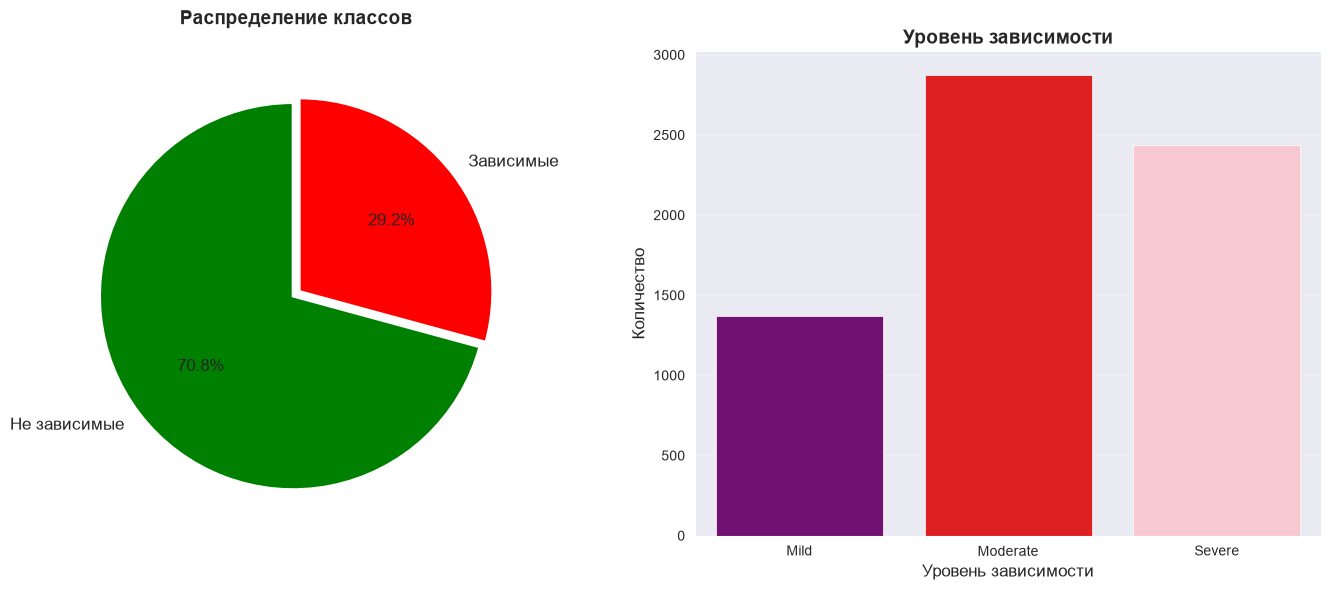

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df, x='addiction_level', ax=axes[1],
              hue='addiction_level',
              palette=["purple", "red", "pink"],
              edgecolor='white', linewidth=0.5,
              legend=False)

axes[1].set_title('Уровень зависимости', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Уровень зависимости', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Pie chart
counts = df['addicted_label'].value_counts()

axes[0].pie(counts,
            labels=['Не зависимые', 'Зависимые'],
            colors=["green", "red"],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.02, 0.02),
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

---

### Как распределена зависимость у представителей разного пола?

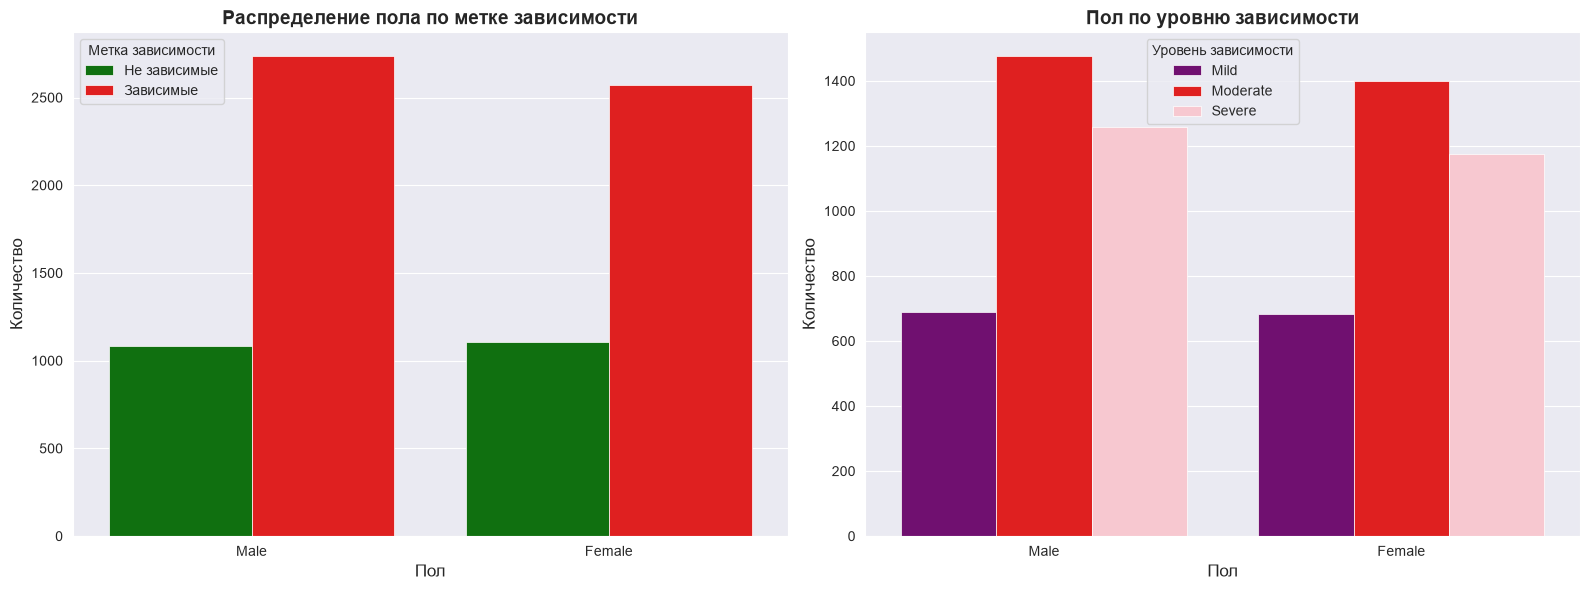

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot
sns.countplot(data=df, x='gender', hue='addicted_label',
              palette=["green", "red"], ax=axes[0],
              edgecolor='white', linewidth=0.5)

axes[0].set_title('Распределение пола по метке зависимости', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Пол', fontsize=12)
axes[0].set_ylabel('Количество', fontsize=12)
axes[0].legend(title='Метка зависимости', labels=['Не зависимые', 'Зависимые'])


# Countplot
sns.countplot(data=df, x='gender', hue='addiction_level',
              palette=["purple", "red", "pink"], ax=axes[1],
              edgecolor='white', linewidth=0.5)

axes[1].set_title('Пол по уровню зависимости', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Пол', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].legend(title='Уровень зависимости')

plt.tight_layout()
plt.show()

##### Ответ - почти поровну

---

### Как распределен возраст среди двух классов:

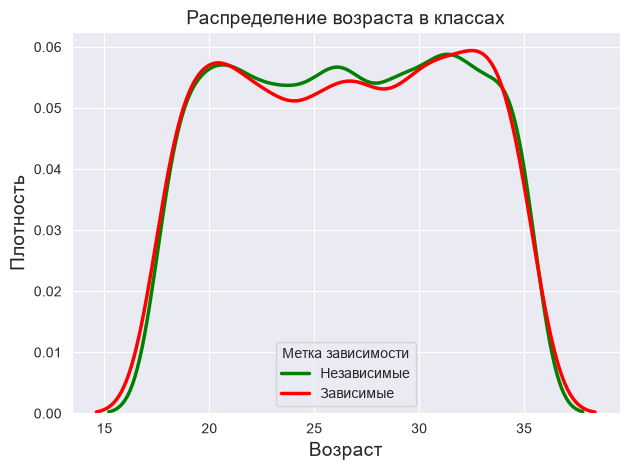

In [113]:
# Kdeplot
sns.kdeplot(data=df, x='age', hue='addicted_label',
            fill=False, linewidth=2.5,
            palette=["red", "green"],
            common_norm=False)

plt.title('Распределение возраста в классах', fontsize=14)
plt.xlabel('Возраст', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.legend(title='Метка зависимости', labels=["Независимые", "Зависимые"])
plt.tight_layout()
plt.show()

##### Практически одинаково, с небольшим различием в пользу зависимых в области 33 лет. Также у представителей 22-30 лет процент отсутствия зависимости больше.

---

### Экранное время для обоих классов:

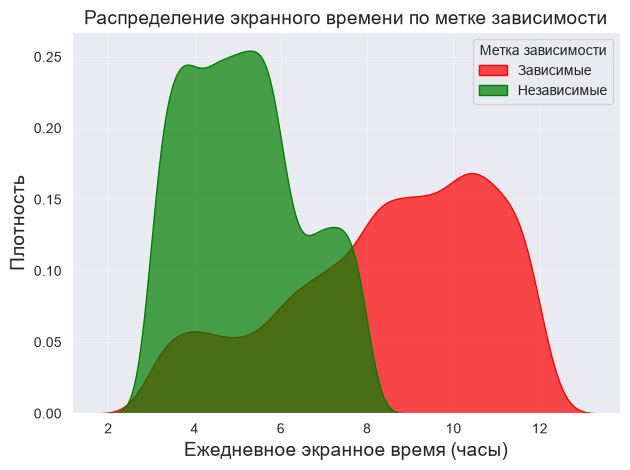

In [114]:
# Kdeplot
sns.kdeplot(data=df, x='daily_screen_time_hours', hue='addicted_label',
            fill=True, alpha=0.7, palette=['green', 'red'],
            common_norm=False)

plt.title('Распределение экранного времени по метке зависимости', fontsize=14)
plt.xlabel('Ежедневное экранное время (часы)', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.legend(title='Метка зависимости', labels=["Зависимые", "Независимые"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Очевидно, что бОльшая часть зависимых людей пользуется устройствами больше 8 часов, тогда как для независимых это верхний предел.

---

### Чем занимаются зависимые люди?

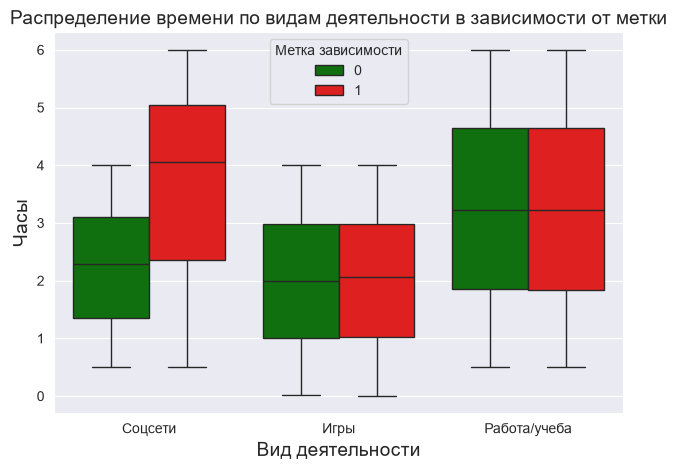

In [115]:
# 3 Boxplots
df_melted = df.melt(id_vars=['addicted_label'],
                    value_vars=['social_media_hours', 'gaming_hours', 'work_study_hours'],
                    var_name='activity', value_name='hours')

sns.boxplot(data=df_melted, x='activity', y='hours', hue='addicted_label',
            palette=["green", "red"])

plt.title('Распределение времени по видам деятельности в зависимости от метки', fontsize=14)
plt.xlabel('Вид деятельности', fontsize=14)
plt.ylabel('Часы', fontsize=14)
plt.xticks([0, 1, 2], ['Соцсети', 'Игры', 'Работа/учеба'])
plt.legend(title='Метка зависимости')
plt.tight_layout()
plt.show()

##### Время, уделенное обеими группами на игры и учебу с работой не отличается практически. Тогда как соцсети показывают разрыв почти в 2 часа в среднем. Соцсети являются главной причиной, где пользователи тратят время.

---

### Отличается ли сон у классов?

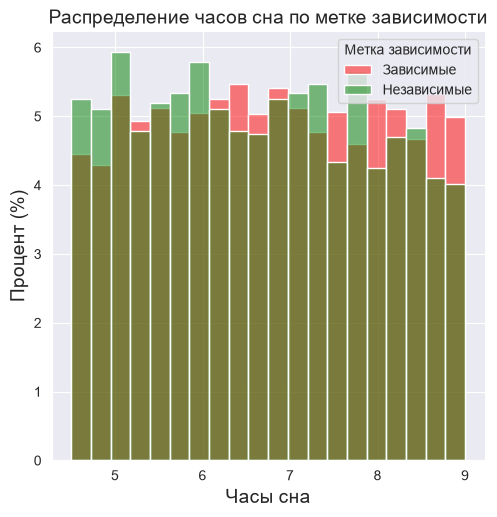

In [116]:
# Displot
sns.displot(data=df, x='sleep_hours', hue='addicted_label',
            kind='hist', fill=True, palette=["green", "red"], common_norm=False,
            stat='percent', legend=False)

plt.title('Распределение часов сна по метке зависимости', fontsize=14)
plt.xlabel('Часы сна', fontsize=14)
plt.ylabel('Процент (%)', fontsize=14)
plt.legend(title='Метка зависимости', labels=["Зависимые", "Независимые"])
plt.show()

##### Странный результат - зависимые спят больше, у независимых недосып.

---

### Влияет ли большое количество уведомлений на зависимость?

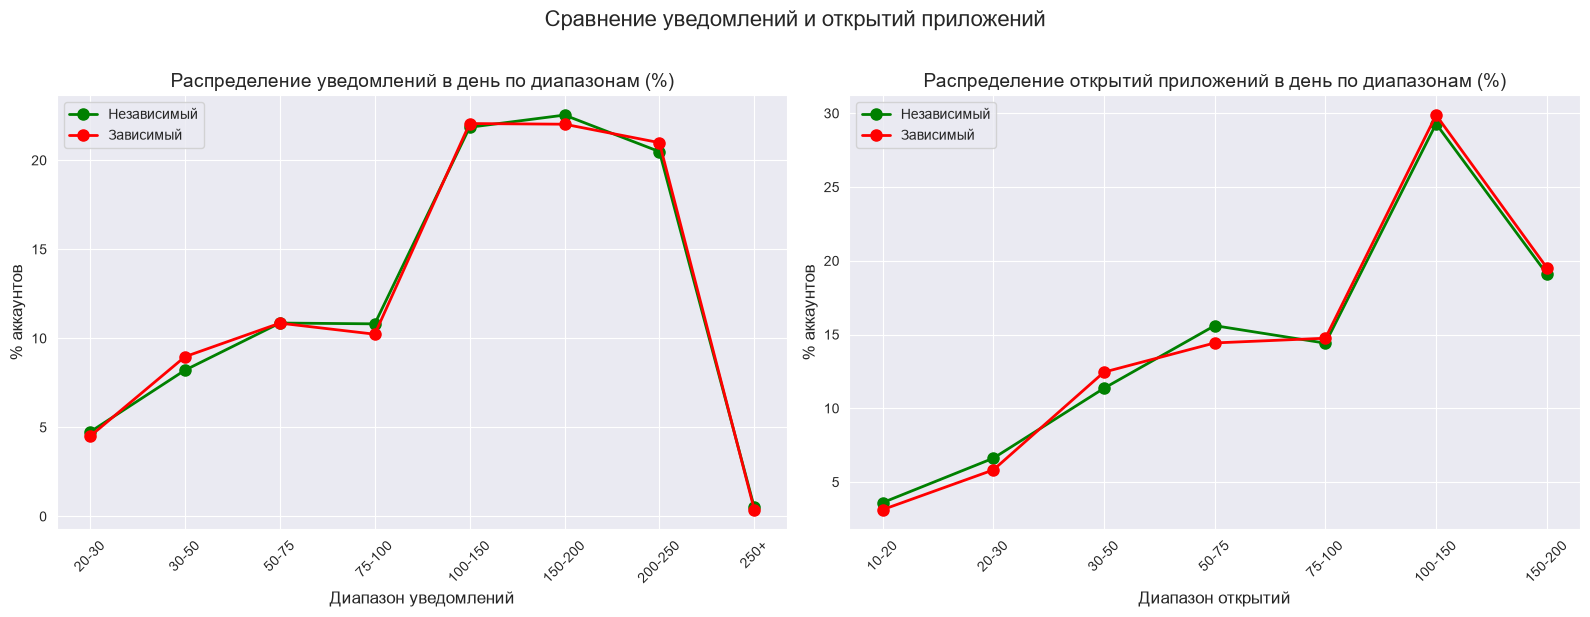

In [117]:
bins = [0, 10, 20, 30, 50, 75, 100, 150, 200, 250, float('inf')]
labels = ['0-10', '10-20', '20-30', '30-50', '50-75', '75-100', '100-150', '150-200', '200-250', '250+']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# notifications_per_day
df['notif_range'] = pd.cut(df['notifications_per_day'], bins=bins, labels=labels, right=False)
cross_tab = pd.crosstab(df['notif_range'], df['addicted_label'], normalize='columns') * 100
cross_tab.plot(kind='line', marker='o', linewidth=2, markersize=8, color=["green", "red"], ax=axes[0])
axes[0].set_title('Распределение уведомлений в день по диапазонам (%)', fontsize=14)
axes[0].set_xlabel('Диапазон уведомлений', fontsize=12)
axes[0].set_ylabel('% аккаунтов', fontsize=12)
axes[0].legend(["Независимый", "Зависимый"])
axes[0].tick_params(axis='x', rotation=45)

# app_opens_per_day
df['app_range'] = pd.cut(df['app_opens_per_day'], bins=bins, labels=labels, right=False)
cross_tab = pd.crosstab(df['app_range'], df['addicted_label'], normalize='columns') * 100
cross_tab.plot(kind='line', marker='o', linewidth=2, markersize=8, color=["green", "red"], ax=axes[1])
axes[1].set_title('Распределение открытий приложений в день по диапазонам (%)', fontsize=14)
axes[1].set_xlabel('Диапазон открытий', fontsize=12)
axes[1].set_ylabel('% аккаунтов', fontsize=12)
axes[1].legend(["Независимый", "Зависимый"])
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение уведомлений и открытий приложений', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##### Ответ - нет

---

### Насколько экранное время зависимых больше здоровых?

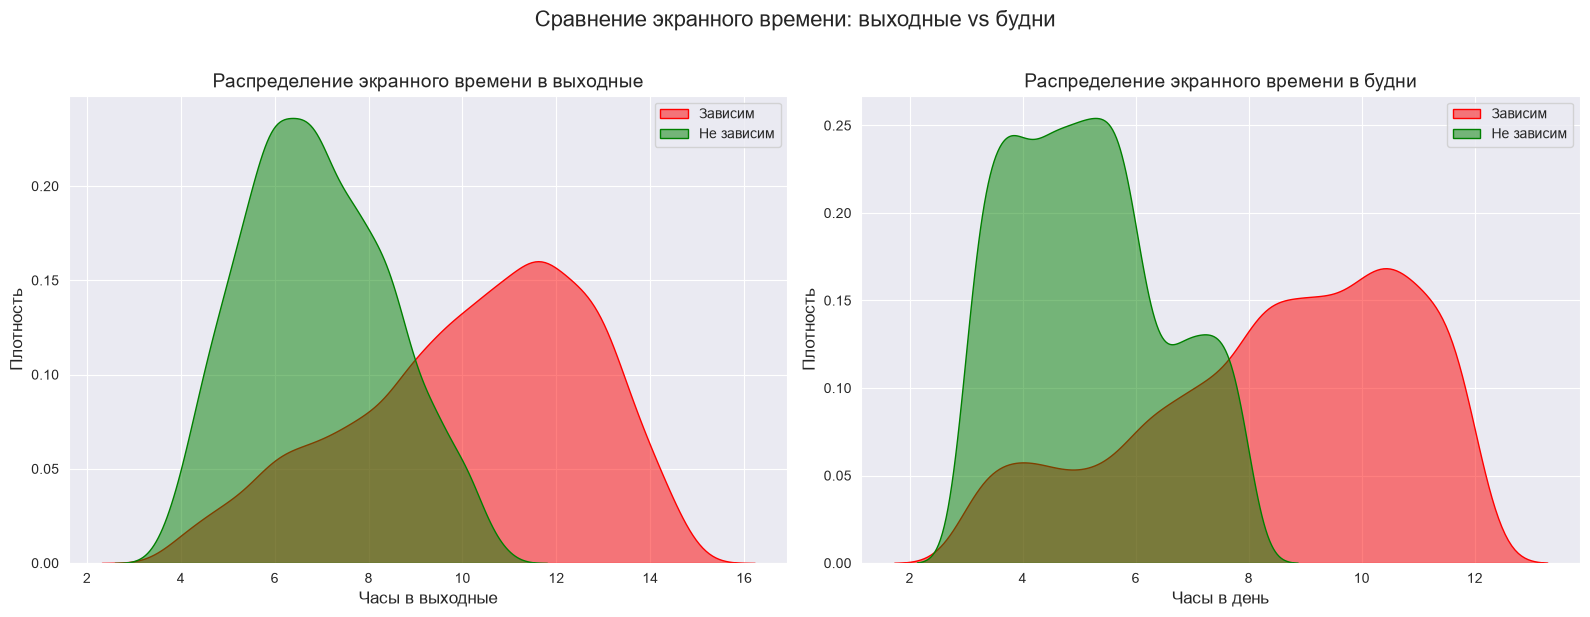

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kdeplot
sns.kdeplot(data=df, x='weekend_screen_time', hue='addicted_label',
            fill=True, alpha=0.5, palette=["green", "red"], common_norm=False, ax=axes[0])
axes[0].set_title('Распределение экранного времени в выходные', fontsize=14)
axes[0].set_xlabel('Часы в выходные', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].legend(['Зависим', 'Не зависим'])

# Kdeplot
sns.kdeplot(data=df, x='daily_screen_time_hours', hue='addicted_label',
            fill=True, alpha=0.5, palette=["green", "red"], common_norm=False, ax=axes[1])
axes[1].set_title('Распределение экранного времени в будни', fontsize=14)
axes[1].set_xlabel('Часы в день', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].legend(['Зависим', 'Не зависим'])

plt.suptitle('Сравнение экранного времени: выходные vs будни', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

##### Основной признак, по которому будем определять зависимость - яркое различие.

---

### Уровень стресса

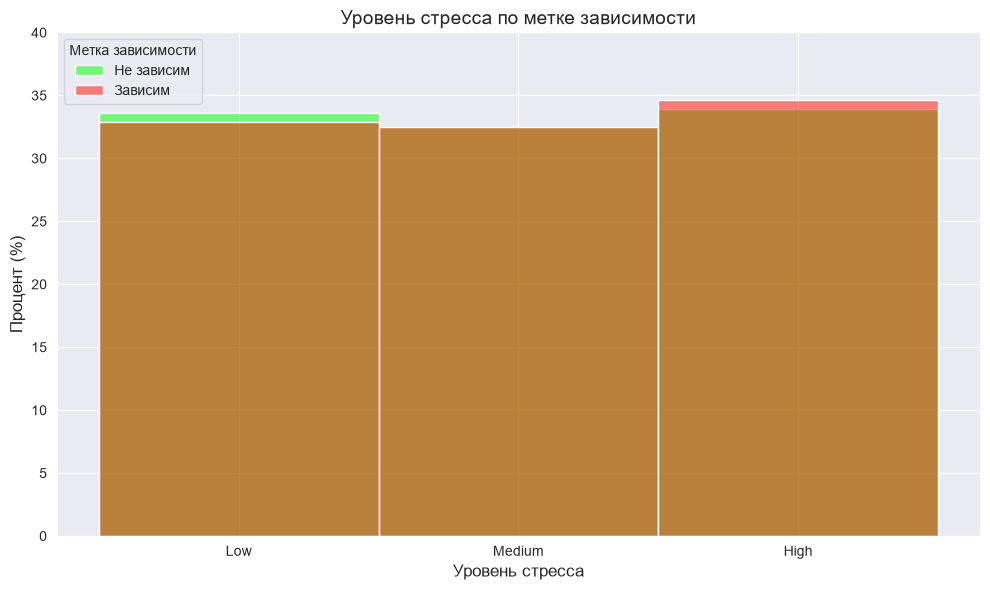

In [119]:
df['stress_level'] = pd.Categorical(df['stress_level'],
                                     categories=['Low', 'Medium', 'High'],
                                     ordered=True)

plt.figure(figsize=(10, 6))

# Histplot
sns.histplot(data=df, x='stress_level', hue='addicted_label',
             fill=True, alpha=0.5, palette=palette,
             stat='percent', common_norm=False, multiple='layer')

plt.title('Уровень стресса по метке зависимости', fontsize=14)
plt.xlabel('Уровень стресса', fontsize=12)
plt.ylabel('Процент (%)', fontsize=12)
plt.legend(title='Метка зависимости', labels=['Не зависим', 'Зависим'])
plt.ylim(0, 40)
plt.tight_layout()
plt.show()

##### Незначительно, но у зависимых, ожидаемо уровень стресса выше.

---

### Влияет ли на учебу или работу зависимость?

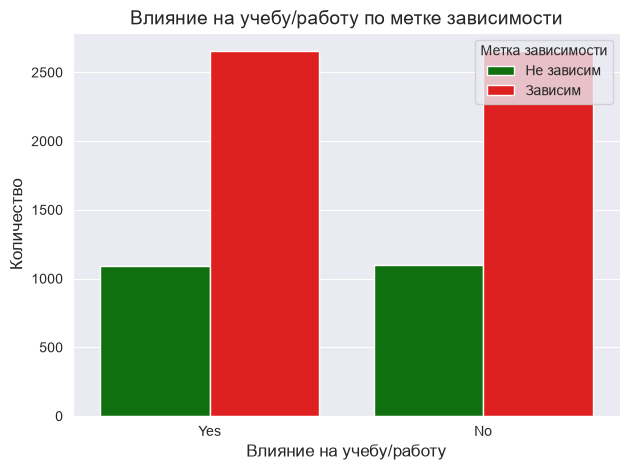

In [120]:
# Countplot
sns.countplot(data=df, x='academic_work_impact', hue='addicted_label', palette=["green", "red"])

plt.title('Влияние на учебу/работу по метке зависимости', fontsize=14)
plt.xlabel('Влияние на учебу/работу', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.legend(title='Метка зависимости', labels=['Не зависим', 'Зависим'])
plt.tight_layout()
plt.show()

##### Ответ - нет

### Корреляция признаков с меткой

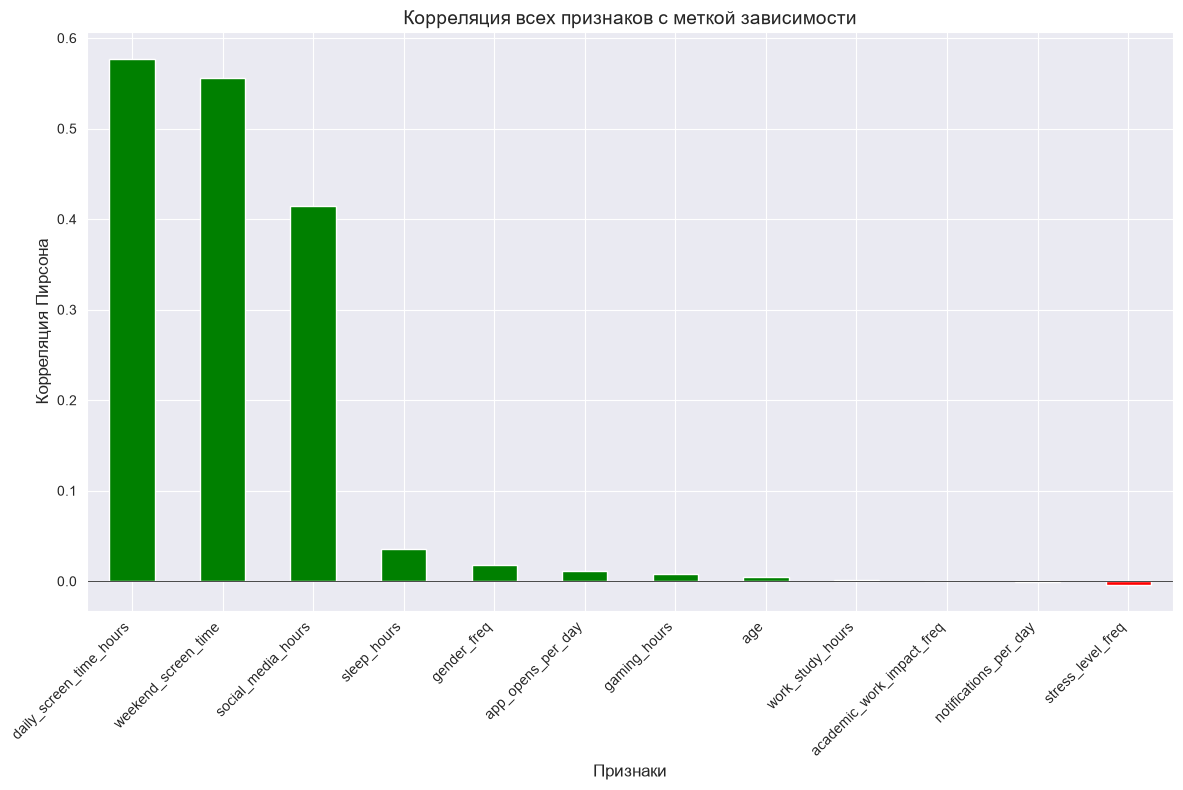

In [121]:
df_encoded = df.copy()
cat_cols = ['gender', 'stress_level', 'academic_work_impact']

# Frequency Encoding
for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    df_encoded[col + '_freq'] = df[col].map(freq)

num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

all_cols = num_cols + [col + '_freq' for col in cat_cols] + ['addicted_label']

correlations = df_encoded[all_cols].corr()['addicted_label'].sort_values(ascending=False)

# Barplot
plt.figure(figsize=(12, 8))
correlations.drop('addicted_label').plot(kind='bar',
                                         color=['green' if x > 0 else 'red' for x in correlations.drop('addicted_label')])
plt.title('Корреляция всех признаков с меткой зависимости', fontsize=14)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Корреляция Пирсона', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Итого - есть 3 очевидно положительно влияющих на зависимость признака, как и было видно ранее на графиках, и один очень слабо отрицательно коррелированный - уровень стресса.